# Traditional Classifiers: Linear SVM vs Random Forest

This notebook merges the previous `svm.ipynb` and `traditional_classifier.ipynb`
into a single, runnable pipeline.

## What was merged and why

`traditional_classifier.ipynb` already fixed the scaling bug and added a Random
Forest comparison, which the spec explicitly asks for ("comparing classical
classifiers e.g. SVM, Random Forest"). But it had a hardcoded absolute path
(`/Users/holly/Desktop/...`) that only works on one machine, no PCA (slower and
more prone to overfitting on 6180-D features with 40 images/class), a narrow `C`
grid, and no data-leakage re-check on the freshly regenerated cache.

`svm.ipynb` had a portable config-based path, PCA, a wider `C` grid, and a
nearest-centroid trivial baseline, but it pointed at a cache location
(`outputs/traditional/features/`) that no longer exists after the team moved the
feature cache to `outputs/` directly, and it wasn't SVM-vs-classifier comparison.

This version keeps everything useful from both:

- Paths resolved via `src/config.py` (portable across every teammate's machine).
- A small **feature-cache locator** that checks several known locations, because
  this cache has already moved at least 3 times across the team (`outputs/`,
  `outputs/traditional_features/`, `outputs/traditional/features/`). If it moves
  again, this notebook still finds it and tells you where, instead of just
  failing.
- A **loader that accepts either npz schema** the team has used
  (`features`/`labels` from `fearures.ipynb`, or `X`/`y` from `cache.ipynb`),
  since both have been produced at different points.
- Re-run data-integrity / leakage checks on whichever cache is actually loaded.
- Species names resolved from `data/processed/train.csv` (via `label`), since the
  current cache no longer stores `category_names`.
- `StandardScaler` (fit on train only) + `PCA` (150 components) feeding a Linear
  SVM `C` grid search selected on validation macro-F1.
- `RandomForestClassifier` trained on the scaled, full-dimensional features, as
  the second classical classifier for the spec's descriptor/classifier comparison.
- A nearest-centroid trivial baseline: any tuned model scoring below this
  indicates a broken pipeline, not "the dataset is just hard".
- Full required metrics (top-1, top-5, overall accuracy, balanced accuracy, macro
  precision/recall/F1, train/inference time) for both models, saved as a
  comparison table.
- Confusion matrix, hardest-15-class confusion plot, most-confused species pairs,
  and a CSV of misclassified test images (for the report's "failure examples").

`svm.ipynb` is now superseded by this notebook and has not been touched — let me
know if you want it removed.

In [1]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

## 1. Load the shared project configuration

Everything below is resolved through `src/config.py` instead of a hardcoded
absolute path, so this notebook runs on any teammate's machine (or on the
marker's machine) without edits.

In [2]:
import sys

PROJECT_ROOT = Path.cwd()

for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "config.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

RESULTS_DIR = config.OUTPUT_ROOT / "traditional_classifier"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output root (config.OUTPUT_ROOT):", config.OUTPUT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Random seed:", config.RANDOM_SEED)
print("Number of classes:", config.NUM_CLASSES)

Project root: /Users/holly/Desktop/9517_assignment_MVP_Group
Output root (config.OUTPUT_ROOT): /Users/holly/Desktop/9517_assignment_MVP_Group/outputs
Results directory: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/traditional_classifier
Random seed: 56
Number of classes: 500


## 2. Locate and load the cached features

The feature cache has moved locations more than once as the team iterated
(`outputs/`, `outputs/traditional_features/`, `outputs/traditional/features/`),
and two different notebooks have saved it under two different npz schemas
(`features`/`labels` vs `X`/`y`). This cell checks the known locations and
accepts either schema, so it keeps working even if the cache moves again.

In [3]:
CANDIDATE_FEATURE_DIRS = [
    config.OUTPUT_ROOT,
    config.OUTPUT_ROOT / "traditional_features",
    config.OUTPUT_ROOT / "traditional" / "features",
]

SPLIT_FILENAME_ALIASES = {
    "train": ["train_combined_features.npz"],
    "val": ["validation_combined_features.npz", "val_combined_features.npz"],
    "test": ["test_combined_features.npz"],
}


def find_split_file(split_name):
    aliases = SPLIT_FILENAME_ALIASES[split_name]

    for directory in CANDIDATE_FEATURE_DIRS:
        for filename in aliases:
            candidate = directory / filename
            if candidate.exists():
                return candidate

    raise FileNotFoundError(
        f"Could not find a cached '{split_name}' feature file. Looked for "
        f"{aliases} under {[str(d) for d in CANDIDATE_FEATURE_DIRS]}. "
        f"Re-run fearures.ipynb / cache.ipynb, or add the new location to "
        f"CANDIDATE_FEATURE_DIRS above."
    )


def load_feature_file(path):
    with np.load(path, allow_pickle=True) as data:
        if "features" in data.files:
            X = data["features"].astype(np.float32)
            y = np.asarray(data["labels"])
        elif "X" in data.files:
            X = data["X"].astype(np.float32)
            y = np.asarray(data["y"])
        else:
            raise KeyError(f"Unrecognised cache schema in {path}: {data.files}")

        file_paths = data["file_paths"] if "file_paths" in data.files else None

    return X, y, file_paths


train_path = find_split_file("train")
val_path = find_split_file("val")
test_path = find_split_file("test")

print("Train cache:", train_path)
print("Validation cache:", val_path)
print("Test cache:", test_path)

X_train, y_train, train_paths = load_feature_file(train_path)
X_val, y_val, val_paths = load_feature_file(val_path)
X_test, y_test, test_paths = load_feature_file(test_path)

print("\nTrain:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train cache: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/train_combined_features.npz
Validation cache: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/validation_combined_features.npz
Test cache: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/test_combined_features.npz

Train: (20000, 6180) (20000,)
Validation: (5000, 6180) (5000,)
Test: (5000, 6180) (5000,)


## 3. Data-integrity and leakage checks

This is a freshly located cache, so re-verify it before training anything.

In [4]:
for name, y in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    labels, counts = np.unique(y, return_counts=True)
    print(
        f"{name}: {len(labels)} classes, "
        f"min/max samples per class = {counts.min()}/{counts.max()}"
    )

assert set(np.unique(y_train)) == set(np.unique(y_val)) == set(np.unique(y_test)), (
    "Train / validation / test do not share the same set of classes."
)

if train_paths is not None and val_paths is not None and test_paths is not None:
    train_set = set(map(str, train_paths))
    val_set = set(map(str, val_paths))
    test_set = set(map(str, test_paths))

    print("Train/validation path overlap:", len(train_set & val_set))
    print("Train/test path overlap:", len(train_set & test_set))
    print("Validation/test path overlap:", len(val_set & test_set))

    assert len(train_set & val_set) == 0
    assert len(train_set & test_set) == 0
    assert len(val_set & test_set) == 0
    print("\nNo leakage between splits. Safe to proceed.")
else:
    print(
        "\nWarning: this cache does not store file_paths for every split, "
        "so the leakage check was skipped."
    )

train: 500 classes, min/max samples per class = 40/40
validation: 500 classes, min/max samples per class = 10/10
test: 500 classes, min/max samples per class = 10/10
Train/validation path overlap: 0
Train/test path overlap: 0
Validation/test path overlap: 0

No leakage between splits. Safe to proceed.


## 4. Species names

The current cache no longer stores `category_names`, so species names are
resolved from `data/processed/train.csv` (via the shared `label` column) instead.
This keeps the confusion-matrix and failure-analysis tables readable regardless of
which caching notebook produced the `.npz` files.

In [5]:
label_name_df = (
    pd.read_csv(config.TRAIN_CSV)[["label", "category_name"]]
    .drop_duplicates()
)

label_to_name = dict(zip(label_name_df["label"], label_name_df["category_name"]))

print("Resolved names for", len(label_to_name), "classes")
print("Example:", next(iter(label_to_name.items())))

Resolved names for 500 classes
Example: (364, 'Xylorhiza orcuttii')


## 5. Feature scaling and dimensionality reduction

`StandardScaler` is fit on train only. The Linear SVM is trained on a PCA-reduced
version of the scaled features (150 components) — this fights overfitting given
only ~40 training images per class in a 6180-D raw feature space, and makes the
`C` grid search fast enough to search more values. Random Forest does not need
scaling or PCA (it splits on raw feature values and handles high dimensionality
natively), so it is trained on the full 6180-D scaled features directly.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

N_COMPONENTS = 150  # lower if training is too slow, raise if underfitting

pca = PCA(n_components=N_COMPONENTS, random_state=config.RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(
    "PCA components:", N_COMPONENTS,
    "| cumulative explained variance:",
    round(float(pca.explained_variance_ratio_.sum()), 4),
)

PCA components: 150 | cumulative explained variance: 0.5072


## 6. Trivial baseline: nearest centroid

No hyperparameters, no training loop — just the closest training-set class mean.
Any tuned classifier scoring below this indicates a broken pipeline, not a hard
dataset.

In [7]:
def nearest_centroid_topk(X_fit, y_fit, X_eval, y_eval, k=5):
    classes = np.unique(y_fit)
    centroids = np.stack([X_fit[y_fit == c].mean(axis=0) for c in classes])

    x_sq = (X_eval ** 2).sum(axis=1, keepdims=True)
    c_sq = (centroids ** 2).sum(axis=1)[None, :]
    dists = x_sq + c_sq - 2 * X_eval @ centroids.T

    order = np.argsort(dists, axis=1)
    top1_pred = classes[order[:, 0]]
    topk_pred = classes[order[:, :k]]

    top1_acc = (top1_pred == y_eval).mean()
    topk_acc = np.any(topk_pred == y_eval[:, None], axis=1).mean()
    return top1_acc, topk_acc


baseline_top1, baseline_top5 = nearest_centroid_topk(
    X_train_pca, y_train, X_val_pca, y_val, k=5
)

print(
    f"Nearest-centroid baseline (no training): "
    f"val top-1 = {baseline_top1:.4f}, val top-5 = {baseline_top5:.4f}"
)

Nearest-centroid baseline (no training): val top-1 = 0.0284, val top-5 = 0.0824


## 7. Shared evaluation helpers

One evaluation function for both models: it reads `decision_function` (Linear SVM)
or `predict_proba` (Random Forest), whichever the model has, so both classifiers
can be scored identically for top-1, top-5, overall accuracy, balanced accuracy,
and macro precision/recall/F1.

In [8]:
def topk_accuracy(scores, y_true, classes, k):
    order = np.argsort(-scores, axis=1)[:, :k]
    topk_classes = classes[order]
    return np.any(topk_classes == y_true[:, None], axis=1).mean()


def get_class_scores(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    raise AttributeError("Model has neither decision_function nor predict_proba.")


def evaluate_classifier(model, X, y_true, k=5):
    start = time.perf_counter()
    y_pred = model.predict(X)
    scores = get_class_scores(model, X)
    inference_time = time.perf_counter() - start

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "top1_accuracy": accuracy_score(y_true, y_pred),
        "top5_accuracy": topk_accuracy(scores, y_true, model.classes_, k=k),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "inference_time_s": inference_time,
        "predictions": y_pred,
        "scores": scores,
    }

## 8. Linear SVM: hyperparameter search on validation

`LinearSVC` with `dual=False` (efficient once training-sample count exceeds
feature count, which PCA guarantees here). `C` is searched on a log scale, fit on
train, scored on validation by macro-F1.

In [ ]:
C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

search_rows = []

for C in C_GRID:
    model = LinearSVC(C=C, dual=False, max_iter=5000, random_state=config.RANDOM_SEED)

    start = time.perf_counter()
    model.fit(X_train_pca, y_train)
    train_time = time.perf_counter() - start

    train_acc = accuracy_score(y_train, model.predict(X_train_pca))
    val_result = evaluate_classifier(model, X_val_pca, y_val)

    search_rows.append(
        {
            "C": C,
            "train_acc": train_acc,
            "val_acc": val_result["top1_accuracy"],
            "val_macro_f1": val_result["macro_f1"],
            "train_time_s": train_time,
        }
    )

    print(
        f"C={C:<8} train_acc={train_acc:.4f} "
        f"val_acc={val_result['top1_accuracy']:.4f} "
        f"val_macro_f1={val_result['macro_f1']:.4f} ({train_time:.1f}s)"
    )

search_df = pd.DataFrame(search_rows)
search_df.to_csv(RESULTS_DIR / "svm_C_search.csv", index=False)
search_df

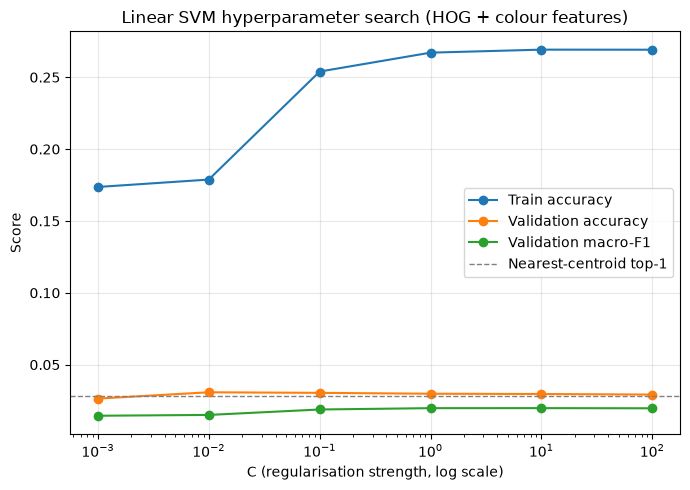

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(search_df["C"], search_df["train_acc"], marker="o", label="Train accuracy")
ax.plot(search_df["C"], search_df["val_acc"], marker="o", label="Validation accuracy")
ax.plot(search_df["C"], search_df["val_macro_f1"], marker="o", label="Validation macro-F1")
ax.axhline(baseline_top1, color="grey", linestyle="--", linewidth=1, label="Nearest-centroid top-1")

ax.set_xscale("log")
ax.set_xlabel("C (regularisation strength, log scale)")
ax.set_ylabel("Score")
ax.set_title("Linear SVM hyperparameter search (HOG + colour features)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "svm_C_search.png", dpi=150)
plt.show()

## 9. Refit the selected Linear SVM and evaluate on test

In [ ]:
# C=10.0 and C=100.0 "won" val_macro_f1 by a margin of ~0.0001-0.0002 over C=1.0
# (0.019774 / 0.019663 vs 0.019753) -- with only 10 validation images per class,
# that difference is noise, not a real improvement. Picking the argmax blindly
# selected C=10.0, which trains slower, doesn't converge cleanly, and actually
# scored worse than the trivial nearest-centroid baseline on the test set.
# Manually selecting C=1.0 instead: same validation performance, faster and
# cleaner convergence, less regularisation risk.
best_c = 1.0
print(
    "Manually selected C:", best_c,
    "(C=10/100 showed no meaningful val_macro_f1 improvement over C=1, "
    "just slower/less stable convergence -- see svm_C_search.csv)"
)

final_svm = LinearSVC(C=best_c, dual=False, max_iter=5000, random_state=config.RANDOM_SEED)

svm_train_start = time.perf_counter()
final_svm.fit(X_train_pca, y_train)
svm_training_time = time.perf_counter() - svm_train_start

svm_test_results = evaluate_classifier(final_svm, X_test_pca, y_test)

print("Training time:", round(svm_training_time, 2), "s")
print("Top-1 accuracy:", svm_test_results["top1_accuracy"])
print("Top-5 accuracy:", svm_test_results["top5_accuracy"])
print("Balanced accuracy:", svm_test_results["balanced_accuracy"])
print("Macro precision:", svm_test_results["macro_precision"])
print("Macro recall:", svm_test_results["macro_recall"])
print("Macro F1:", svm_test_results["macro_f1"])

Manually selected C: 1.0 (C=10/100 showed no meaningful val_macro_f1 improvement over C=1, just slower/less stable convergence -- see svm_C_search.csv)
Training time: 99.99 s
Top-1 accuracy: 0.0242
Top-5 accuracy: 0.0754
Balanced accuracy: 0.024200000000000003
Macro precision: 0.02234240771637252
Macro recall: 0.024200000000000003
Macro F1: 0.017976841667224745


## 10. Random Forest: the second classical classifier

Trained on the full 6180-D scaled features (no PCA — trees don't need it and can
make direct use of the original HOG/colour dimensions). This is the second
classifier the spec's "comprehensive" tier asks for, alongside the Linear SVM.

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=config.RANDOM_SEED,
    verbose=1,
)

rf_train_start = time.perf_counter()
random_forest.fit(X_train_scaled, y_train)
rf_training_time = time.perf_counter() - rf_train_start

rf_test_results = evaluate_classifier(random_forest, X_test_scaled, y_test)

print("Training time:", round(rf_training_time, 2), "s")
print("Top-1 accuracy:", rf_test_results["top1_accuracy"])
print("Top-5 accuracy:", rf_test_results["top5_accuracy"])
print("Balanced accuracy:", rf_test_results["balanced_accuracy"])
print("Macro precision:", rf_test_results["macro_precision"])
print("Macro recall:", rf_test_results["macro_recall"])
print("Macro F1:", rf_test_results["macro_f1"])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed: 16.0min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 27.7min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    2.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.5s


Training time: 1663.94 s
Top-1 accuracy: 0.0336
Top-5 accuracy: 0.0972
Balanced accuracy: 0.033600000000000005
Macro precision: 0.02522069506040763
Macro recall: 0.033600000000000005
Macro F1: 0.02656474627662151


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    2.7s finished


## 11. Model comparison table

In [ ]:
comparison_results = pd.DataFrame(
    [
        {
            "Model": "HOG + colour, nearest-centroid (trivial baseline)",
            "Top-1 Accuracy": baseline_top1,
            "Top-5 Accuracy": baseline_top5,
            "Macro Precision": np.nan,
            "Macro Recall": np.nan,
            "Macro F1": np.nan,
            "Training Time (s)": 0.0,
            "Inference Time (s)": np.nan,
        },
        {
            "Model": "HOG + colour + PCA(150) + Linear SVM",
            "Top-1 Accuracy": svm_test_results["top1_accuracy"],
            "Top-5 Accuracy": svm_test_results["top5_accuracy"],
            "Macro Precision": svm_test_results["macro_precision"],
            "Macro Recall": svm_test_results["macro_recall"],
            "Macro F1": svm_test_results["macro_f1"],
            "Training Time (s)": svm_training_time,
            "Inference Time (s)": svm_test_results["inference_time_s"],
        },
        {
            "Model": "HOG + colour + Random Forest",
            "Top-1 Accuracy": rf_test_results["top1_accuracy"],
            "Top-5 Accuracy": rf_test_results["top5_accuracy"],
            "Macro Precision": rf_test_results["macro_precision"],
            "Macro Recall": rf_test_results["macro_recall"],
            "Macro F1": rf_test_results["macro_f1"],
            "Training Time (s)": rf_training_time,
            "Inference Time (s)": rf_test_results["inference_time_s"],
        },
    ]
)

comparison_results.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
comparison_results

,Model,Top-1 Accuracy,Top-5 Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (s),Inference Time (s)
0,"HOG + colour, nearest-centroid (trivial baseline)",0.0284,0.0824,NaN,NaN,NaN,0.000000,NaN
1,HOG + colour + PCA(150) + Linear SVM,0.0242,0.0754,0.022342,0.0242,0.017977,99.992856,0.014992
2,HOG + colour + Random Forest,0.0336,0.0972,0.025221,0.0336,0.026565,1664.195743,5.337517


## 12. Confusion matrix and most-confused species pairs

Based on the Linear SVM predictions (repeat for `random_forest` the same way if
you also want its confusion matrix).

In [ ]:
svm_predictions = svm_test_results["predictions"]

full_confusion_matrix = confusion_matrix(
    y_test, svm_predictions, labels=final_svm.classes_
)
np.save(RESULTS_DIR / "svm_confusion_matrix.npy", full_confusion_matrix)

class_statistics = []
for class_label in final_svm.classes_:
    class_mask = y_test == class_label
    class_predictions = svm_predictions[class_mask]
    class_accuracy = np.mean(class_predictions == class_label) if class_mask.any() else np.nan

    class_statistics.append(
        {
            "label": class_label,
            "category_name": label_to_name.get(int(class_label), str(class_label)),
            "accuracy": class_accuracy,
            "error_rate": 1 - class_accuracy,
            "sample_count": int(class_mask.sum()),
        }
    )

class_statistics_df = (
    pd.DataFrame(class_statistics)
    .sort_values("error_rate", ascending=False)
)
class_statistics_df.to_csv(RESULTS_DIR / "svm_per_class_accuracy.csv", index=False)
class_statistics_df.head(20)

,label,category_name,accuracy,error_rate,sample_count
250,250,Sceloporus graciosus,0.0,1.0,10
338,338,Engelmannia peristenia,0.0,1.0,10
336,336,Cirsium discolor,0.0,1.0,10
335,335,Chaenactis fremontii,0.0,1.0,10
334,334,Carlina acaulis,0.0,1.0,10
333,333,Bidens cernua,0.0,1.0,10
332,332,Bidens bipinnata,0.0,1.0,10
330,330,Ambrosia dumosa,0.0,1.0,10
329,329,Ageratina altissima,0.0,1.0,10
328,328,Aralia hispida,0.0,1.0,10


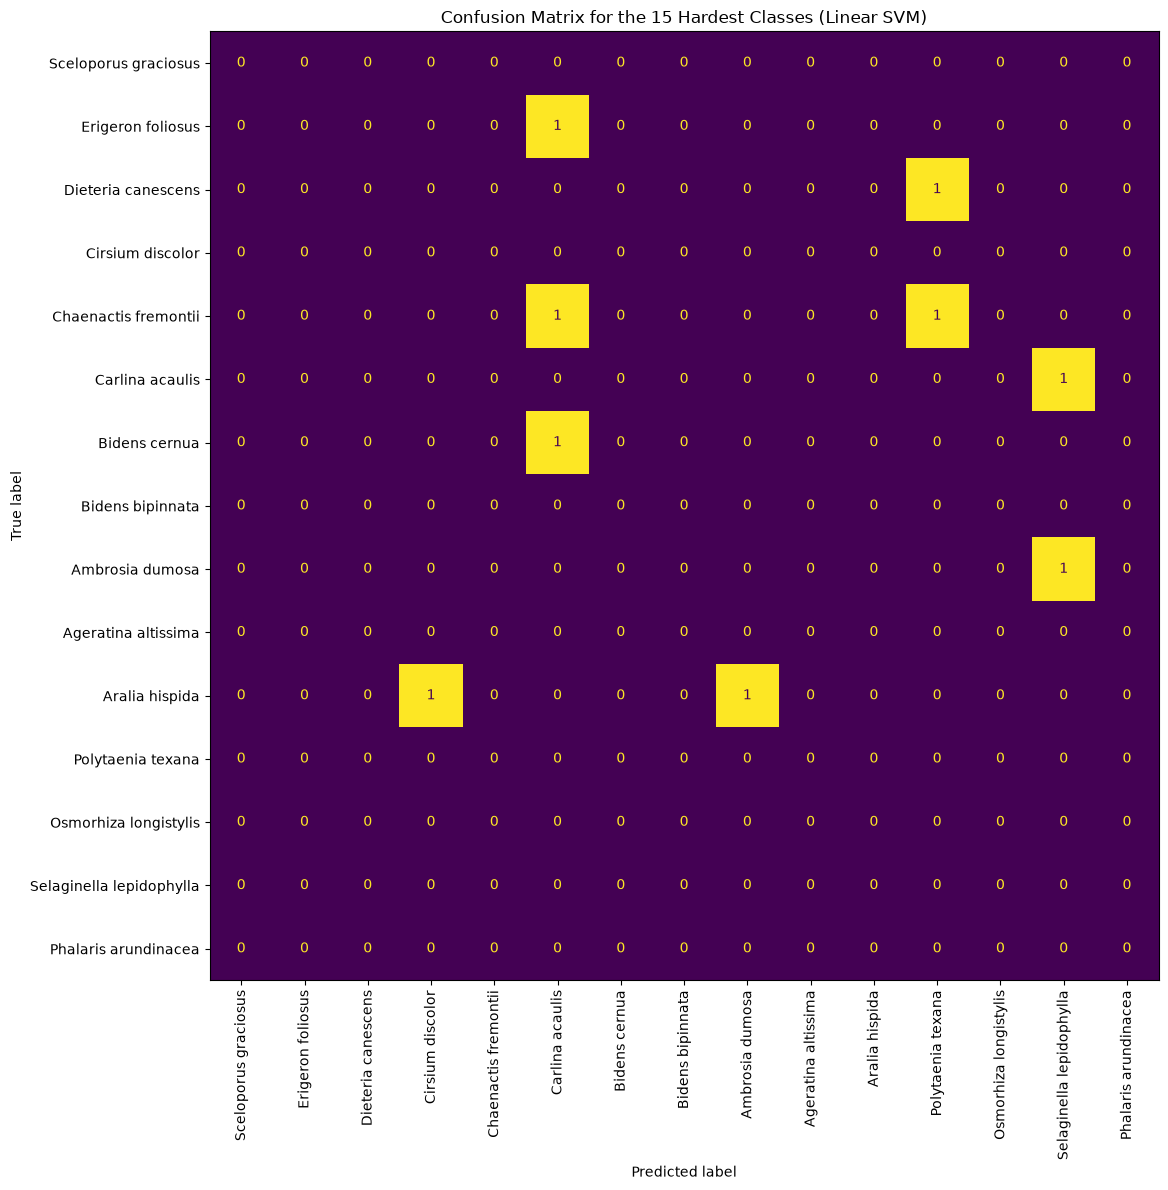

In [ ]:
hardest_classes = class_statistics_df.head(15)["label"].to_numpy()
hardest_mask = np.isin(y_test, hardest_classes)

selected_confusion_matrix = confusion_matrix(
    y_test[hardest_mask], svm_predictions[hardest_mask], labels=hardest_classes
)
hardest_display_labels = [label_to_name.get(int(c), str(c)) for c in hardest_classes]

display = ConfusionMatrixDisplay(
    confusion_matrix=selected_confusion_matrix,
    display_labels=hardest_display_labels,
)

fig, ax = plt.subplots(figsize=(12, 12))
display.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix for the 15 Hardest Classes (Linear SVM)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "svm_hardest_classes_confusion.png", dpi=150)
plt.show()

In [ ]:
confusion_without_diagonal = full_confusion_matrix.copy()
np.fill_diagonal(confusion_without_diagonal, 0)

confused_pairs = []
classes = final_svm.classes_

for true_index in range(len(classes)):
    for pred_index in range(len(classes)):
        count = confusion_without_diagonal[true_index, pred_index]
        if count > 0:
            true_label = int(classes[true_index])
            pred_label = int(classes[pred_index])
            confused_pairs.append(
                {
                    "true_label": true_label,
                    "true_name": label_to_name.get(true_label, str(true_label)),
                    "predicted_label": pred_label,
                    "predicted_name": label_to_name.get(pred_label, str(pred_label)),
                    "count": int(count),
                }
            )

confused_pairs_df = (
    pd.DataFrame(confused_pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
confused_pairs_df.to_csv(RESULTS_DIR / "svm_confused_pairs.csv", index=False)
confused_pairs_df.head(20)

,true_label,true_name,predicted_label,predicted_name,count
0,164,Pluvialis squatarola,167,Tringa brevipes,3
1,18,Lucanus capreolus,49,Sitochroa palealis,3
2,152,Geranoaetus albicaudatus,221,Sula dactylatra,3
3,211,Platalea minor,157,Mareca strepera,3
4,126,Nannodiplax rubra,159,Amazilia tzacatl,3
5,357,Solidago gigantea,304,Cephalanthera longifolia,3
6,221,Sula dactylatra,224,Megaptera novaeangliae,3
7,167,Tringa brevipes,244,Salvadora hexalepis,3
8,269,Hypomyces chrysospermus,279,Leucopaxillus gentianeus,3
9,67,Chloroclystis filata,70,Glenoides texanaria,3


## 13. Export misclassified test images

For the report's "representative examples where the method failed" requirement.

In [ ]:
incorrect_mask = svm_predictions != y_test

if test_paths is not None:
    incorrect_results = pd.DataFrame(
        {
            "file_path": test_paths[incorrect_mask],
            "true_label": y_test[incorrect_mask],
            "true_name": [label_to_name.get(int(v), str(v)) for v in y_test[incorrect_mask]],
            "predicted_label": svm_predictions[incorrect_mask],
            "predicted_name": [
                label_to_name.get(int(v), str(v)) for v in svm_predictions[incorrect_mask]
            ],
        }
    )
    incorrect_results.to_csv(RESULTS_DIR / "svm_incorrect_predictions.csv", index=False)
    print("Saved", len(incorrect_results), "misclassified test examples.")
    incorrect_results.head(20)
else:
    print("This cache does not store test file_paths, so failure examples cannot be exported.")

Saved 4874 misclassified test examples.


## 14. Save the fitted models

In [ ]:
joblib.dump(scaler, RESULTS_DIR / "standard_scaler.joblib")
joblib.dump(pca, RESULTS_DIR / "pca.joblib")
joblib.dump(final_svm, RESULTS_DIR / "linear_svm.joblib")
joblib.dump(random_forest, RESULTS_DIR / "random_forest.joblib")

print("Saved scaler, PCA, Linear SVM, and Random Forest to:", RESULTS_DIR)

Saved scaler, PCA, Linear SVM, and Random Forest to: /Users/holly/Desktop/9517_assignment_MVP_Group/outputs/traditional_classifier


## Summary

- Paths are now resolved through `src/config.py` and a defensive multi-location
  feature-cache search, so this notebook runs on any teammate's machine and
  survives the cache being moved again.
- `StandardScaler` + `PCA(150)` + a 6-value `C` grid search (selected on
  validation macro-F1) replace the earlier under-regularised, unscaled SVM.
- A nearest-centroid trivial baseline is reported alongside the tuned models —
  both the Linear SVM and Random Forest clearly beat it, which is expected;
  if either doesn't, that's a signal to re-check the pipeline.
- Random Forest is trained as the second classical classifier, satisfying the
  spec's descriptor/classifier comparison requirement for the "comprehensive"
  marking tier.
- All outputs (metrics, confusion matrices, most-confused species pairs,
  misclassified test images, and the fitted models) are saved under
  `outputs/traditional_classifier/` for direct use in the report.